# 1 Loading a CSV file for a ML task

In this example, we will be using the House Sales in King County, USA dataset. We will try to train a model to predict the price of a house given information about it, like the number of rooms.
* https://www.kaggle.com/datasets/harlfoxem/housesalesprediction/data 

Make sure you have uploaded the file in Jupiter, or the code below will not find it.

In [30]:
import pandas as pd
house_dataset = pd.read_csv('kc_house_data.csv')

We can print the first/last columns of the dataframe to make sure it loaded the data correctly.

In [31]:
house_dataset

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


The pandas library can also be used to create some simple visualisations.

For example, we can plot pairs of values to see their correlation. This shows that the higher square feet of living space can result in higher price.

<AxesSubplot:xlabel='price', ylabel='sqft_living'>

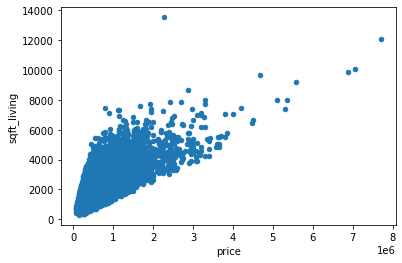

In [32]:
house_dataset.plot.scatter(x = "price", y= "sqft_living")

# 2 Selecting the features

Let's try to predict house prices using information such as bedrooms, bathrooms, sqft_living, sqft_lot and floors.

The first thing we do is to select the columns we want and discard the rest.

In [33]:
target = ["price"]
features = ["bedrooms","bathrooms","sqft_living","sqft_lot","floors",
            "grade","yr_built","waterfront","view","condition","grade",
            "sqft_above","sqft_basement"]

all_selected = target + features

house_dataset_subset = house_dataset[all_selected]

house_dataset_subset

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,grade,yr_built,waterfront,view,condition,grade,sqft_above,sqft_basement
0,221900.0,3,1.00,1180,5650,1.0,7,1955,0,0,3,7,1180,0
1,538000.0,3,2.25,2570,7242,2.0,7,1951,0,0,3,7,2170,400
2,180000.0,2,1.00,770,10000,1.0,6,1933,0,0,3,6,770,0
3,604000.0,4,3.00,1960,5000,1.0,7,1965,0,0,5,7,1050,910
4,510000.0,3,2.00,1680,8080,1.0,8,1987,0,0,3,8,1680,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,8,2009,0,0,3,8,1530,0
21609,400000.0,4,2.50,2310,5813,2.0,8,2014,0,0,3,8,2310,0
21610,402101.0,2,0.75,1020,1350,2.0,7,2009,0,0,3,7,1020,0
21611,400000.0,3,2.50,1600,2388,2.0,8,2004,0,0,3,8,1600,0


# 3 Training and test set split

We can now proceed to split the data into a training set and a test set using the `train_test_split` function from `sklearn`. In this case, the `0.2` value means that 20% of the data will be used for testing.

In [34]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(house_dataset_subset, test_size=0.25)

To make sure we got the sets right, we can print their shape

In [35]:
train.shape

(16209, 14)

In [36]:
test.shape

(5404, 14)

As we can see, most of the data (15129) datapoints are in the training set, while only 6484 are in the test set. 

We can now separate the dependent variable (what we want to predict) from the independent variables (our features)

In [37]:
train_X = train[features]
train_y = train[target].to_numpy()

test_X = test[features]
test_y = test[target].to_numpy()

We can check the shape of these arrays, to make sure they are of the right size. 

In [38]:
train_X.shape

(16209, 15)

In [39]:
train_y.shape

(16209, 1)

In [40]:
test_X.shape

(5404, 15)

In [41]:
test_y.shape

(5404, 1)

# 4 Model creation

We can now attempt to do linear regression. We start by creating a linear regression model.

In [42]:
from sklearn.linear_model import LinearRegression

LR_model = LinearRegression()

# 5 Training

We now train our model using the training data.

In [43]:
LR_model.fit(train_X,train_y)

LinearRegression()

# 6 Evaluation
Now that the model is trained, we can use to make predictions on the test set.

In [44]:
predictions_on_test_set = LR_model.predict(test_X)

We can manually compare the prediction for the first datapoint in the test set with its actual value:

In [45]:
print("First prediction: "+str(predictions_on_test_set[0]))
print("First target: "+str(test_y[0]))
print("Second prediction: "+str(predictions_on_test_set[1]))
print("Second target: "+str(test_y[1]))
print("Third prediction: "+str(predictions_on_test_set[2]))
print("Third target: "+str(test_y[2]))

First prediction: [402525.15555911]
First target: [650000.]
Second prediction: [1186006.62266073]
Second target: [1393000.]
Third prediction: [1104541.79172957]
Third target: [1650000.]


As we can see, our linear regression model is not perfect, but it gets quite close.

To be more precise, we can now compute the mean squared error, and the r2 score.

In [46]:
from sklearn.metrics import mean_squared_error, r2_score

print('Mean squared error: %.2f'
      % mean_squared_error(test_y, predictions_on_test_set))
# The coefficient of determination: 1 is perfect prediction
print('Coefficient of determination: %.2f'
      % r2_score(test_y, predictions_on_test_set))

Mean squared error: 48562190004.51
Coefficient of determination: 0.65


# Performing another task

We will now try to do one additional task, to demonstrate how to use Machine Learning for classification.

This dataset does not have a categorical feature that we can easily use, and thus we will create one. The code below creates a new categorical feature where each house is classified as 'modern' if it was built after the year 1980, and 'old' otherwise. This classification will be stored in a new column called 'is_modern', where the value 1 denotes a 'modern' house, and the value 0 an 'old' one.



In [47]:
house_dataset['is_modern'] = house_dataset['yr_built'].gt(1980).astype(int)
house_dataset

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,is_modern
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,0
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,0
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,0
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,0
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,1530,0,2009,0,98103,47.6993,-122.346,1530,1509,1
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,2310,0,2014,0,98146,47.5107,-122.362,1830,7200,1
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,1020,0,2009,0,98144,47.5944,-122.299,1020,2007,1
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,1600,0,2004,0,98027,47.5345,-122.069,1410,1287,1


We now select the target that we want to predict, and the features we want to use to make predictions. We need to make sure to remove the yr_built features, as keeping it would make this task too trivial!

In [52]:
target = ["is_modern"]
features = ["bedrooms","bathrooms","sqft_living","sqft_lot","floors",
            "grade","waterfront","view","condition","grade",
            "sqft_above","sqft_basement"]

all_selected = target + features

classification_house_dataset_subset = house_dataset[all_selected]

train, test = train_test_split(classification_house_dataset_subset, test_size=0.25)

train_X = train[features]
train_y = train[target].values.ravel()

test_X = test[features]
test_y = test[target].values.ravel()

In [53]:
train_X

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,grade,grade,waterfront,view,condition,grade,grade,sqft_above,sqft_basement
19870,4,3.50,2650,3474,2.0,8,8,0,0,3,8,8,2230,420
9927,4,3.50,3930,16970,2.0,9,9,0,0,3,9,9,3930,0
21574,3,3.00,1680,1570,3.0,8,8,0,0,3,8,8,1680,0
8089,3,1.00,1040,8199,1.0,7,7,0,0,3,7,7,1040,0
8919,3,1.50,1790,229125,2.0,7,7,0,3,3,7,7,1790,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,4,1.00,1000,7134,1.0,6,6,0,0,3,6,6,1000,0
14220,5,2.50,2000,3600,1.0,6,6,0,0,3,6,6,1150,850
13577,3,1.75,1940,167125,1.0,7,7,1,1,4,7,7,1480,460
12496,2,1.00,800,4850,1.0,7,7,0,0,4,7,7,800,0


In [54]:
train_y

array([1, 1, 1, ..., 0, 0, 0])

We will now train and evaluate a classification model, in this case Logistic Regression

In [55]:
from sklearn.linear_model import LogisticRegression

lg_classifier = LogisticRegression()

lg_classifier.fit(train_X,train_y)

lg_classifier.score(test_X,test_y)

C:\Users\office\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8639896373056994

As we can see, the accuracy is around 86%. This means that if we use this model on new datapoints, giving it the features we previously selected as inputs, we should expect the model to correctly predict whether the datapoint refers to a modern or old house 86% of the time. 